In [22]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

import torch
import torch.nn as nn
import torch.optim as optim

In [23]:
df = pd.read_csv('D:\mca_aiml_lab\mca_env\Datasets\Iris.csv')

<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_8976\312474960.py:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  df = pd.read_csv('D:\mca_aiml_lab\mca_env\Datasets\Iris.csv')


In [24]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [25]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [26]:
df.drop('Id', axis=1, inplace=True)


In [27]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [28]:
# Encode the target label
le = LabelEncoder()
y = le.fit_transform(y)

In [37]:
scalar = StandardScaler()

X_scalar = scalar.fit_transform(X)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X_scalar, y, test_size=0.2, random_state=42)

In [39]:
# Converts into tensors

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [40]:
# Create Model Class

class IrisNN(nn.Module):

    def __init__(self):
        super(IrisNN, self).__init__()
        self.fc1 = nn.Linear(4, 16)  # Input layer to hidden layer
        self.fc2 = nn.Linear(16, 8)   # Hidden layer to output layer
        self.fc3 = nn.Linear(8, 3)   # Output layer to output layer

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [41]:
model = IrisNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [42]:
epochs = 100

train_losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())


    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [1/100], Loss: 1.1321
Epoch [2/100], Loss: 1.1284
Epoch [3/100], Loss: 1.1248
Epoch [4/100], Loss: 1.1212
Epoch [5/100], Loss: 1.1177
Epoch [6/100], Loss: 1.1142
Epoch [7/100], Loss: 1.1108
Epoch [8/100], Loss: 1.1074
Epoch [9/100], Loss: 1.1040
Epoch [10/100], Loss: 1.1007
Epoch [11/100], Loss: 1.0974
Epoch [12/100], Loss: 1.0941
Epoch [13/100], Loss: 1.0908
Epoch [14/100], Loss: 1.0875
Epoch [15/100], Loss: 1.0843
Epoch [16/100], Loss: 1.0810
Epoch [17/100], Loss: 1.0777
Epoch [18/100], Loss: 1.0745
Epoch [19/100], Loss: 1.0712
Epoch [20/100], Loss: 1.0678
Epoch [21/100], Loss: 1.0645
Epoch [22/100], Loss: 1.0612
Epoch [23/100], Loss: 1.0578
Epoch [24/100], Loss: 1.0543
Epoch [25/100], Loss: 1.0508
Epoch [26/100], Loss: 1.0473
Epoch [27/100], Loss: 1.0438
Epoch [28/100], Loss: 1.0402
Epoch [29/100], Loss: 1.0365
Epoch [30/100], Loss: 1.0328
Epoch [31/100], Loss: 1.0290
Epoch [32/100], Loss: 1.0252
Epoch [33/100], Loss: 1.0213
Epoch [34/100], Loss: 1.0173
Epoch [35/100], Loss: 1

In [43]:
with torch.no_grad():
    model.eval()
    test_outputs = model(X_test)
    _, predicted = torch.max(test_outputs, 1)
    accuracy = (predicted == y_test).float().mean()
    print(f'Test Accuracy: {accuracy:.4f}')

Test Accuracy: 0.7667


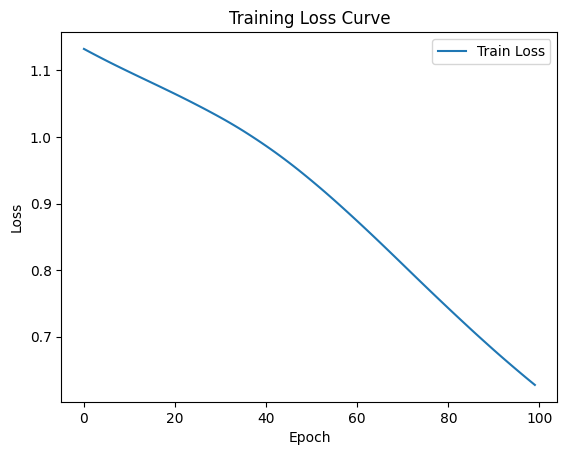

In [44]:
# Plot Loss Curve

plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.show()